In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import P300
from hoda.hoda import HODA, MLSVD
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.analysis.plotting import paired_plot, meta_analysis_plot, summary_plot
from sklearn.base import BaseEstimator, ClassifierMixin
from toeplitzlda.classification import ToeplitzLDA
from sklearn.svm import SVC
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 64

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
    #bi2013a(),
    #bi2014a(),
    #bi2014b(),
    #bi2015a(),
    #bi2015b(),
    BNCI2014008(),
    #BNCI2014009(),
    #BNCI2015003(),
    #DemonsP300(),
    #EPFLP300(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019()

]
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets,
    suffix="hoda", overwrite=True,n_jobs=12,
        data_size=dict(policy='per_class', value=[75,77]), n_perms=[5,5],
)

In [3]:
for dataset in datasets:
    print(dataset)
    dataset.download()

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ..

In [4]:
import tensorly as tl
tl.set_backend('cupy', local_threadsafe=False)

In [5]:
import numpy as np

class ToeplitzLDAWrapper(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        n_epochs, n_channels, n_samples = X.shape
        self.tlda_ = ToeplitzLDA(n_channels=n_channels, data_is_channel_prime=False)
        X = X.reshape(n_epochs, -1)
        return self.tlda_.fit(X, y)

    def decision_function(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.decision_function(X)

    def predict(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict(X)

    def predict_proba(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict_proba(X)



def lagged_tensor(X, y=None):    
    window = 0.4
    max_lag = 0.4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

def reshape(X, y=None):
    return X.reshape((X.shape[0],-1))

def tril_reshape(X):
    tril_idc = np.tril_indices(X.shape[-1])
    Xt = np.zeros((*X.shape[:2], len(tril_idc[0])))
    for i in range(Xt.shape[0]):
        for c in range(Xt.shape[1]):
            Xt[i,c] = X[i,c][tril_idc]
    Xt = Xt.reshape((Xt.shape[0],-1))
    return Xt


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC
import cupy

pipelines = dict()



pipelines['tHODA-st'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(max_iter=128, tol=1e-6,
         shrinkage=('oas','oas'), initialize='ones',
         toeplitz=(1,), rank=(5,5), solver='ratio-svd'),
    FunctionTransformer(reshape),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
"""
pipelines['tHODA-hankel'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    FunctionTransformer(lagged_tensor),
    #MLSVD(modes=(0,),rank=(16,)),
    HODA(max_iter=128, tol=1e-6,
         shrinkage=('oas', 'oas', 'oas'), initialize='ones',
         toeplitz=(1,2), rank=None, solver='diff-svd'),
    FunctionTransformer(tril_reshape),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
"""
pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)
"""
pipelines['LDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    FunctionTransformer(reshape),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
"""

"\npipelines['LDA'] = make_pipeline(\n    Scaler(scalings='mean', with_mean=False),\n    FunctionTransformer(reshape),\n    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')\n)\n"

In [13]:
results = evaluation.process(pipelines)

008-2014-WithinSession: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [02:38<00:00, 19.81s/it]


In [14]:
results

,score,time,samples,data_size,permutation,subject,session,channels,n_sessions,dataset,pipeline
0,0.736582,0.925870,150.0,150.0,1.0,1,session_0,8,1,008-2014,tHODA-st
1,0.723357,0.927010,154.0,154.0,1.0,1,session_0,8,1,008-2014,tHODA-st
2,0.707612,1.365484,150.0,150.0,2.0,1,session_0,8,1,008-2014,tHODA-st
3,0.714908,0.753320,154.0,154.0,2.0,1,session_0,8,1,008-2014,tHODA-st
4,0.778061,2.146477,150.0,150.0,3.0,1,session_0,8,1,008-2014,tHODA-st
...,...,...,...,...,...,...,...,...,...,...,...
155,0.894694,0.366809,154.0,154.0,3.0,8,session_0,8,1,008-2014,tLDA
156,0.919143,0.370393,150.0,150.0,4.0,8,session_0,8,1,008-2014,tLDA
157,0.917510,0.386378,154.0,154.0,4.0,8,session_0,8,1,008-2014,tLDA
158,0.900071,0.096622,150.0,150.0,5.0,8,session_0,8,1,008-2014,tLDA


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


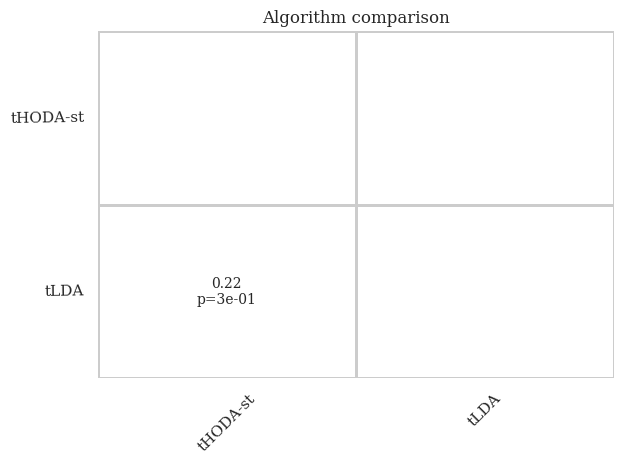

In [15]:
stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

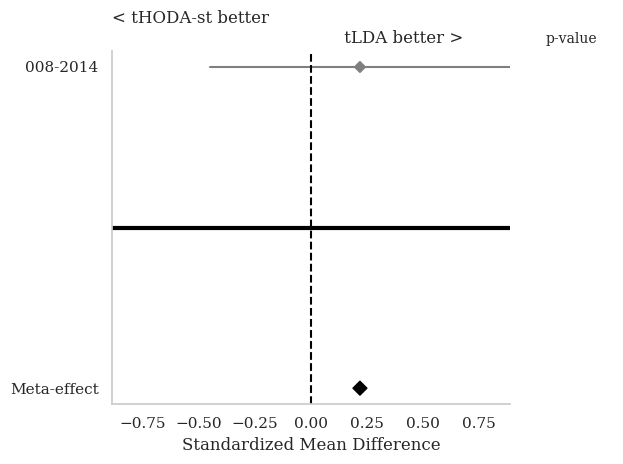

In [16]:

_=meta_analysis_plot(stats, "tLDA", "tHODA-st")


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


KeyError: 'HODA-st'

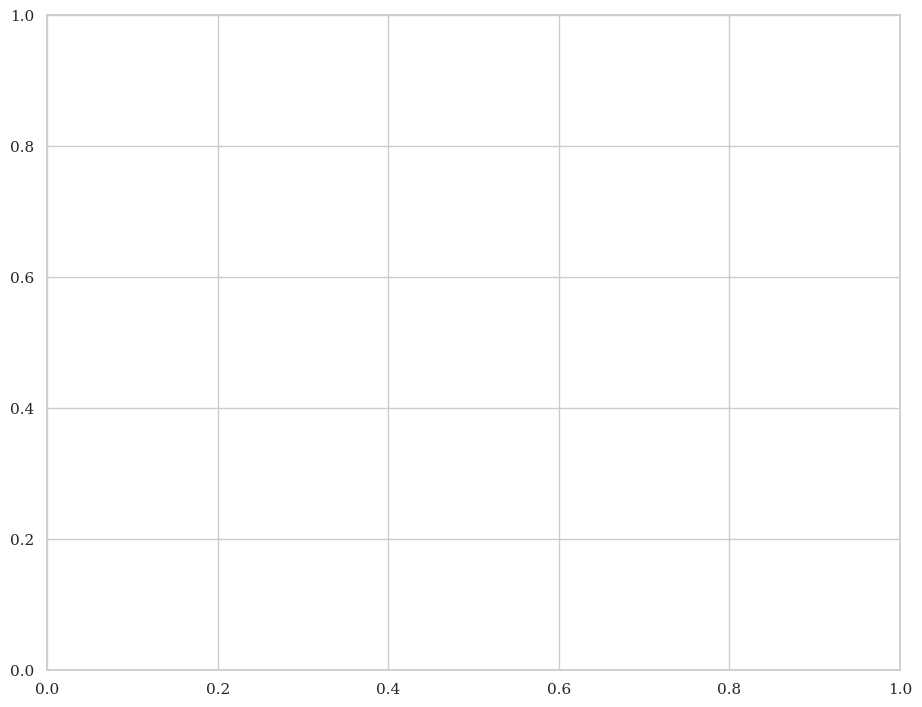

In [17]:
_ = paired_plot(results, "HODA-st", "tHODA-st")

#_=paired_plot(results, "HODA-st", "HODA-hankel")
#_=paired_plot(results, "tLDA", "HODA-hankel")
#_=paired_plot(results, "LDA", "HODA-hankel")